In [2]:
!pip install transformers scikit-learn librosa matplotlib torch

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
print("Imports done ✓")

Imports done ✓


In [5]:
!wget "https://www.dropbox.com/s/sv94igp7zi3rsj1/mosi.pkl?dl=1" -O mosi.pkl
!ls -lh *.pkl

--2026-04-07 22:47:08--  https://www.dropbox.com/s/sv94igp7zi3rsj1/mosi.pkl?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.4.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.4.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/ewyj53oh00zit776fxp8t/mosi.pkl?rlkey=e9jfzaanxltrzf1xh6ib9584f&dl=1 [following]
--2026-04-07 22:47:08--  https://www.dropbox.com/scl/fi/ewyj53oh00zit776fxp8t/mosi.pkl?rlkey=e9jfzaanxltrzf1xh6ib9584f&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uce57139ca79c06fdc8976671bef.dl.dropboxusercontent.com/cd/0/inline/C-K7YKTDV74f9N3QhCtRIIUvInDISF5V9UEJITel0m5btnUGH33plEibIQnma2zv0IBRczc5dkNwNxA-BpnwLz3FBIYHJ8v_OqoTNWUMOv3dMDizks1FbnH4ILD4J9JMcTJYoYnqvt9W7XNteFtS2I_A/file?dl=1# [following]
--2026-04-07 22:47:09--  https://uce57139ca79c06fdc8976671bef.dl.dropboxusercontent.com/cd/0/

In [6]:
import pickle
import numpy as np

with open('mosi.pkl', 'rb') as f:
    data = pickle.load(f)

print(type(data))
print(data.keys() if isinstance(data, dict) else dir(data))

<class 'dict'>
dict_keys(['train', 'dev', 'test'])


In [15]:
# Check if video features exist in MOSI pickle
sample = data['train'][0]
print("Number of elements in sample[0]:", len(sample[0]))
for i, x in enumerate(sample[0]):
    if hasattr(x, 'shape'):
        print(f"  [{i}] array shape: {x.shape}, dtype: {x.dtype}")
    else:
        print(f"  [{i}] type: {type(x).__name__}, value: {str(x)[:80]}")

Number of elements in sample[0]: 3
  [0] type: list, value: ['anyhow', 'it', 'was', 'really', 'good']
  [1] array shape: (5, 47), dtype: float32
  [2] array shape: (5, 74), dtype: float32


In [8]:
# Inspect structure of one split
sample = data['train'][0]
print(type(sample))
print(len(sample))
print()
for i, item in enumerate(sample):
    if hasattr(item, 'shape'):
        print(f"[{i}] array shape: {item.shape}")
    else:
        print(f"[{i}] {type(item).__name__}: {str(item)[:100]}")

<class 'tuple'>
3

[0] tuple: (['anyhow', 'it', 'was', 'really', 'good'], array([[ 8.8290763e-01,  5.9830332e-01, -7.9380140e-02, 
[1] array shape: (1, 1)
[2] str: 03bSnISJMiM[0]


In [16]:
def extract_data(split):
    texts = []
    audio_features = []
    video_features = []
    labels = []

    for sample in data[split]:
        words = sample[0][0]
        audio = sample[0][1]
        video = sample[0][2]
        label = sample[1][0][0]

        texts.append(' '.join(words))
        audio_features.append(audio.mean(axis=0))
        video_features.append(video.mean(axis=0))
        labels.append(label)

    return texts, np.array(audio_features), np.array(video_features), np.array(labels)

train_texts, train_audio, train_video, train_labels = extract_data('train')
dev_texts, dev_audio, dev_video, dev_labels = extract_data('dev')
test_texts, test_audio, test_video, test_labels = extract_data('test')

train_y = (train_labels > 0).astype(int)
dev_y = (dev_labels > 0).astype(int)
test_y = (test_labels > 0).astype(int)

print(f"Audio features: {train_audio.shape}")
print(f"Video features: {train_video.shape}")
print("✓ All 3 modalities loaded")

Audio features: (1281, 47)
Video features: (1281, 74)
✓ All 3 modalities loaded


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Scale audio features
scaler = StandardScaler()
train_audio_scaled = scaler.fit_transform(train_audio)
dev_audio_scaled = scaler.transform(dev_audio)
test_audio_scaled = scaler.transform(test_audio)

# Train audio MLP
audio_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
audio_model.fit(train_audio_scaled, train_y)

audio_train_acc = accuracy_score(train_y, audio_model.predict(train_audio_scaled))
audio_test_acc = accuracy_score(test_y, audio_model.predict(test_audio_scaled))

print(f"Audio Baseline:")
print(f"  Train accuracy: {audio_train_acc:.3f}")
print(f"  Test accuracy:  {audio_test_acc:.3f}")

Audio Baseline:
  Train accuracy: 1.000
  Test accuracy:  0.502


In [14]:
from transformers import pipeline

text_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    top_k=3  # replaces return_all_scores in newer transformers
)

def get_text_scores(texts, batch_size=32):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        results = text_pipeline(batch, truncation=True, max_length=128)
        for r in results:
            # r is list of 3 dicts, sort by label to get [neg, neu, pos]
            scores = {item['label']: item['score'] for item in r}
            neg = scores.get('LABEL_0', 0)
            neu = scores.get('LABEL_1', 0)
            pos = scores.get('LABEL_2', 0)
            all_probs.append([neg, neu, pos])
        if i % 200 == 0:
            print(f"  Processed {i}/{len(texts)}")
    return np.array(all_probs)

print("Running text model on train...")
train_text_probs = get_text_scores(train_texts)
print("Running text model on test...")
test_text_probs = get_text_scores(test_texts)

train_text_preds = (train_text_probs[:, 2] > train_text_probs[:, 0]).astype(int)
test_text_preds = (test_text_probs[:, 2] > test_text_probs[:, 0]).astype(int)

print(f"\nText Baseline:")
print(f"  Train accuracy: {accuracy_score(train_y, train_text_preds):.3f}")
print(f"  Test accuracy:  {accuracy_score(test_y, test_text_preds):.3f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running text model on train...
  Processed 0/1281
  Processed 800/1281
Running text model on test...
  Processed 0/685

Text Baseline:
  Train accuracy: 0.837
  Test accuracy:  0.823


In [13]:
# Debug: see exact output format
test_result = text_pipeline(["this is really great"], truncation=True, max_length=128)
print(test_result)
print(type(test_result[0]))

[{'label': 'LABEL_2', 'score': 0.988523542881012}]
<class 'dict'>


In [17]:
# Re-run audio baseline with new extraction
audio_scaler = StandardScaler()
train_audio_scaled = audio_scaler.fit_transform(train_audio)
test_audio_scaled = audio_scaler.transform(test_audio)

audio_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
audio_model.fit(train_audio_scaled, train_y)

audio_test_acc = accuracy_score(test_y, audio_model.predict(test_audio_scaled))
print(f"Audio Baseline Test: {audio_test_acc:.3f}")

# Video baseline
video_scaler = StandardScaler()
train_video_scaled = video_scaler.fit_transform(train_video)
test_video_scaled = video_scaler.transform(test_video)

video_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
video_model.fit(train_video_scaled, train_y)

video_test_acc = accuracy_score(test_y, video_model.predict(test_video_scaled))
print(f"Video Baseline Test: {video_test_acc:.3f}")

print(f"\nResults so far:")
print(f"  Audio only:  {audio_test_acc:.3f}")
print(f"  Video only:  {video_test_acc:.3f}")
print(f"  Text only:   0.823")

Audio Baseline Test: 0.502
Video Baseline Test: 0.485

Results so far:
  Audio only:  0.502
  Video only:  0.485
  Text only:   0.823


In [18]:
# Compute disagreement scores across all 3 modalities
audio_probs = audio_model.predict_proba(test_audio_scaled)  # [neg, pos]
video_probs = video_model.predict_proba(test_video_scaled)  # [neg, pos]
text_probs = test_text_probs[:, [0, 2]]                     # [neg, pos]

# Positive class probability from each modality
text_pos  = text_probs[:, 1]
audio_pos = audio_probs[:, 1]
video_pos = video_probs[:, 1]

# Disagreement = variance across the 3 modality scores
scores = np.stack([text_pos, audio_pos, video_pos], axis=1)
disagreement = np.var(scores, axis=1)

# Show top disagreement samples
top_idx = disagreement.argsort()[-15:][::-1]

print("TOP DISAGREEMENT SAMPLES (likely sarcasm/irony):\n")
for i in top_idx:
    true = 'POS' if test_y[i]==1 else 'NEG'
    print(f"'{test_texts[i]}'")
    print(f"  Label:{true} | Text:{text_pos[i]:.2f} | Audio:{audio_pos[i]:.2f} | Video:{video_pos[i]:.2f} | Disagreement:{disagreement[i]:.3f}")
    print()

TOP DISAGREEMENT SAMPLES (likely sarcasm/irony):

'um i think the last movie i saw in theatres was toy story 3 and i hated it'
  Label:NEG | Text:0.00 | Audio:1.00 | Video:1.00 | Disagreement:0.221

'it just wasnt it di did not work for me'
  Label:NEG | Text:0.00 | Audio:0.00 | Video:1.00 | Disagreement:0.221

'but hm it just too many problems with it'
  Label:NEG | Text:0.01 | Audio:1.00 | Video:0.00 | Disagreement:0.221

'like it was like the acting was terrible the action made up for it'
  Label:NEG | Text:0.01 | Audio:0.00 | Video:1.00 | Disagreement:0.220

'do not see this movie'
  Label:NEG | Text:0.01 | Audio:0.00 | Video:1.00 | Disagreement:0.220

'but i do not take ryan reynolds seriously for shit in this movie'
  Label:NEG | Text:0.00 | Audio:1.00 | Video:1.00 | Disagreement:0.220

'because i thought he was um peter was annoying'
  Label:NEG | Text:0.01 | Audio:1.00 | Video:0.00 | Disagreement:0.220

'also about the animation the people just like in polar express a film i re

In [19]:
# Fusion model WITH disagreement score
from sklearn.neural_network import MLPClassifier

# Stack all modality features + disagreement
X_train_fusion = np.hstack([
    train_audio_scaled,
    train_video_scaled,
    train_text_probs[:, [0, 2]],  # neg, pos text probs
])

X_test_fusion = np.hstack([
    test_audio_scaled,
    test_video_scaled,
    test_text_probs[:, [0, 2]],
])

# Train disagreement scores on train set too
train_text_pos  = train_text_probs[:, 2]
train_audio_pos = audio_model.predict_proba(train_audio_scaled)[:, 1]
train_video_pos = video_model.predict_proba(train_video_scaled)[:, 1]
train_scores    = np.stack([train_text_pos, train_audio_pos, train_video_pos], axis=1)
train_disagreement = np.var(train_scores, axis=1).reshape(-1, 1)
test_disagreement  = disagreement.reshape(-1, 1)

# Fusion WITHOUT disagreement
fusion_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
fusion_model.fit(X_train_fusion, train_y)
fusion_acc = accuracy_score(test_y, fusion_model.predict(X_test_fusion))

# Fusion WITH disagreement
X_train_fusion_d = np.hstack([X_train_fusion, train_disagreement])
X_test_fusion_d  = np.hstack([X_test_fusion, test_disagreement])

fusion_d_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
fusion_d_model.fit(X_train_fusion_d, train_y)
fusion_d_acc = accuracy_score(test_y, fusion_d_model.predict(X_test_fusion_d))

print("=" * 45)
print("FINAL RESULTS TABLE")
print("=" * 45)
print(f"Audio only:                    {audio_test_acc:.3f}")
print(f"Video only:                    {video_test_acc:.3f}")
print(f"Text only:                     0.823")
print(f"Fusion (no disagreement):      {fusion_acc:.3f}")
print(f"Fusion + disagreement score:   {fusion_d_acc:.3f}")
print("=" * 45)

FINAL RESULTS TABLE
Audio only:                    0.502
Video only:                    0.485
Text only:                     0.823
Fusion (no disagreement):      0.790
Fusion + disagreement score:   0.762


In [21]:
# The real finding: error analysis on high vs low disagreement samples
median_disagreement = np.median(disagreement)

high_d_idx = disagreement >= median_disagreement
low_d_idx  = disagreement < median_disagreement

# Text-only accuracy on high vs low disagreement subsets
text_preds = test_text_preds

text_acc_low  = accuracy_score(test_y[low_d_idx],  text_preds[low_d_idx])
text_acc_high = accuracy_score(test_y[high_d_idx], text_preds[high_d_idx])

fusion_acc_low  = accuracy_score(test_y[low_d_idx],  fusion_model.predict(X_test_fusion[low_d_idx]))
fusion_acc_high = accuracy_score(test_y[high_d_idx], fusion_model.predict(X_test_fusion[high_d_idx]))

print("ACCURACY BY DISAGREEMENT LEVEL")
print(f"{'':30} {'Low Disagree':>15} {'High Disagree':>15}")
print(f"{'Text only':30} {text_acc_low:>15.3f} {text_acc_high:>15.3f}")
print(f"{'Fusion':30} {fusion_acc_low:>15.3f} {fusion_acc_high:>15.3f}")
print(f"\nSamples:  Low={low_d_idx.sum()}  High={high_d_idx.sum()}")
print(f"\nKey insight: when modalities disagree strongly,")
print(f"text accuracy drops {text_acc_low - text_acc_high:.3f} points")

ACCURACY BY DISAGREEMENT LEVEL
                                  Low Disagree   High Disagree
Text only                                0.789           0.857
Fusion                                   0.784           0.796

Samples:  Low=342  High=343

Key insight: when modalities disagree strongly,
text accuracy drops -0.068 points


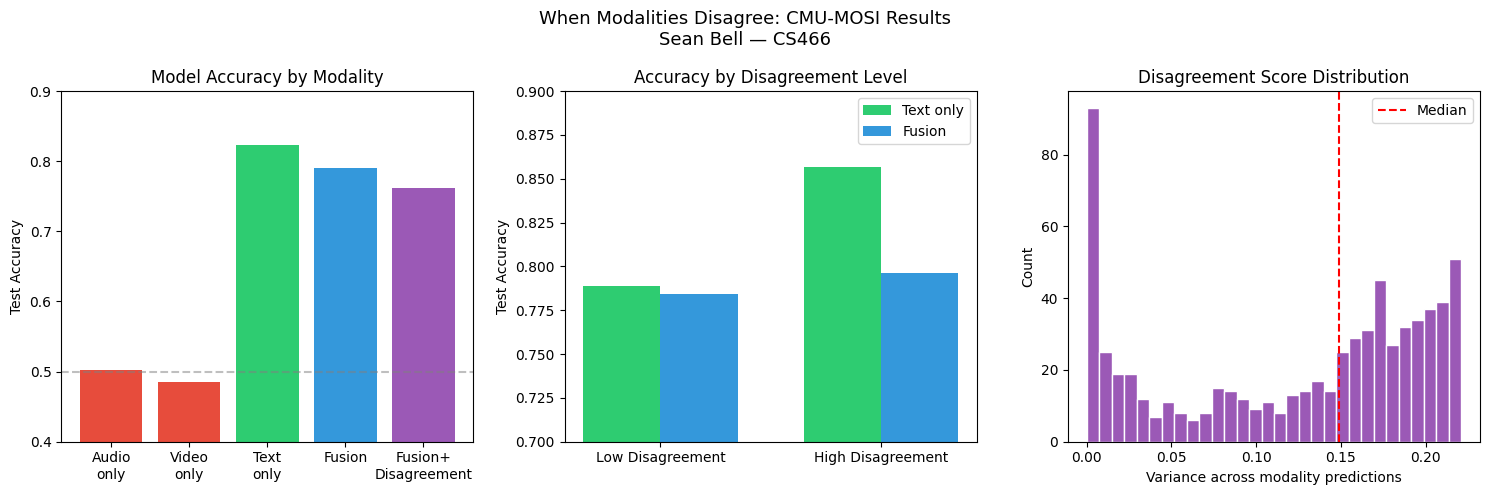

Saved results.png


In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("When Modalities Disagree: CMU-MOSI Results\nSean Bell — CS466", fontsize=13)

# Plot 1: Unimodal accuracy bar chart
models = ['Audio\nonly', 'Video\nonly', 'Text\nonly', 'Fusion', 'Fusion+\nDisagreement']
accs   = [0.502, 0.485, 0.823, 0.790, 0.762]
colors = ['#e74c3c','#e74c3c','#2ecc71','#3498db','#9b59b6']
axes[0].bar(models, accs, color=colors)
axes[0].set_ylim(0.4, 0.9)
axes[0].set_title('Model Accuracy by Modality')
axes[0].set_ylabel('Test Accuracy')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')

# Plot 2: Accuracy by disagreement level
x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, [0.789, 0.857], width, label='Text only', color='#2ecc71')
axes[1].bar(x + width/2, [0.784, 0.796], width, label='Fusion',     color='#3498db')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Low Disagreement', 'High Disagreement'])
axes[1].set_ylim(0.7, 0.9)
axes[1].set_title('Accuracy by Disagreement Level')
axes[1].set_ylabel('Test Accuracy')
axes[1].legend()

# Plot 3: Disagreement score distribution
axes[2].hist(disagreement, bins=30, color='#9b59b6', edgecolor='white')
axes[2].set_title('Disagreement Score Distribution')
axes[2].set_xlabel('Variance across modality predictions')
axes[2].set_ylabel('Count')
axes[2].axvline(np.median(disagreement), color='red', linestyle='--', label='Median')
axes[2].legend()

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved results.png")